In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, kruskal, mannwhitneyu

([Swap(5), Reversion(4), Insertion(3), Slide(2)])

([ETN(6), RS(6), SPS(5), SRPS(2)])

([MinMaxSwap(5), SourceDepotSwap(2, data), ENS(1)])

In [3]:
def plot_boxplots(filename, title):
    data = np.load(filename)
    outer_array = data[data.files[0]] 

    plt.figure()
    plt.title(f"{title}")
    plt.boxplot(outer_array.T, notch=True)
    plt.xlabel("Array Index")
    plt.ylabel("Values")
    plt.show()

In [4]:
# Deterministic
filename = 'FX_values_0.npz'
data = np.load(filename)
data = data["FX_values_"]
a0 = data[0, :]
b0 = data[1, :]
c0 = data[2, :]

# Stochastic
filename = 'FX_values_1.npz'
data = np.load(filename)
data = data["FX_values_"]
a1 = data[0, :]
b1 = data[1, :]
c1 = data[2, :]

## Deterministic

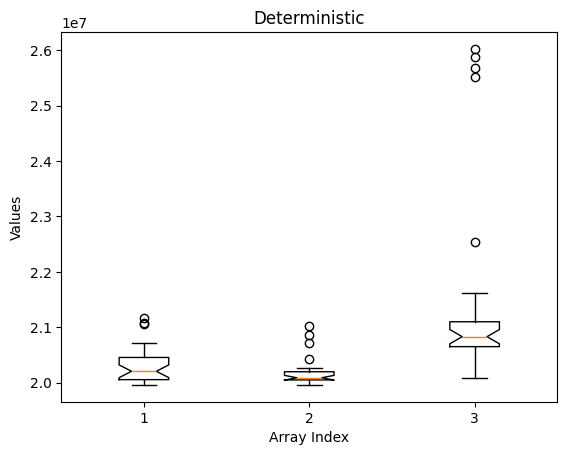

In [5]:
filename = 'FX_values_0.npz'
plot_boxplots(filename, "Deterministic")

In [6]:
print(shapiro(a0))
print(shapiro(b0))
print(shapiro(c0))

# Based on the results, none of them are normally distributed.

ShapiroResult(statistic=0.8370827949468628, pvalue=0.0003365488412559096)
ShapiroResult(statistic=0.7036949381043974, pvalue=1.7666009476228599e-06)
ShapiroResult(statistic=0.586534092233567, pvalue=5.01888049576454e-08)


In [7]:
# perform Kruskal-Wallis test
# H0: the medians of the groups are equal

# does not assume normality

print(kruskal(a0, b0, c0))

# since H0 is rejected, the medians are not equal.

KruskalResult(statistic=41.5021219729711, pvalue=9.72587581410227e-10)


In [8]:
# perform Mann-Whitney U test
# H0: the distribution underlying the two samples is the same

# does not assume normality

#  The alternative hypothesis is that the distribution of the first sample is stochastically 
# less than the distribution of the second sample. This means that observations in the first sample 
# tend to have smaller values than those in the second sample.

print(f"a vs b: {mannwhitneyu(a0, b0, alternative='greater')}")
print(f"a vs c: {mannwhitneyu(a0, c0, alternative='less')}")
print(f"b vs c: {mannwhitneyu(b0, c0, alternative='less')}")

a vs b: MannwhitneyuResult(statistic=555.0, pvalue=0.06115050200451758)
a vs c: MannwhitneyuResult(statistic=99.0, pvalue=1.097518957934115e-07)
b vs c: MannwhitneyuResult(statistic=62.0, pvalue=5.049896714012413e-09)


there are significant differences between groups a and c, and between groups b and c, but not between groups a and b.

## Stochastic

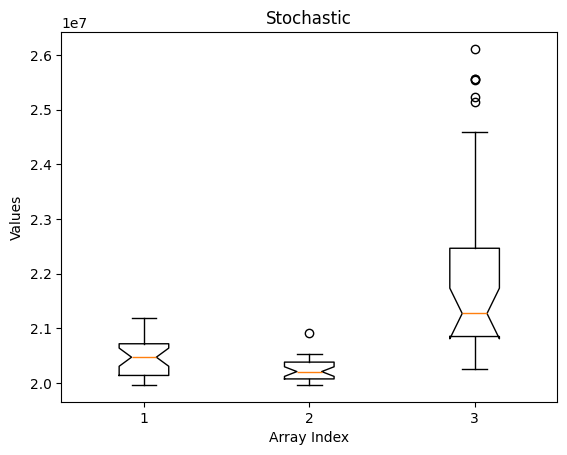

In [9]:
filename = 'FX_values_1.npz'
plot_boxplots(filename, "Stochastic")

In [10]:
print(shapiro(a1))
print(shapiro(b1))
print(shapiro(c1))

# Based on the results, A is normally distributed. B and C are not.

ShapiroResult(statistic=0.9442917185961291, pvalue=0.11871844097430578)
ShapiroResult(statistic=0.9149020245950146, pvalue=0.019821235730607276)
ShapiroResult(statistic=0.7709549030490181, pvalue=2.0239278752283338e-05)


In [11]:
print(kruskal(a1, b1, c1))

# since H0 is rejected, the medians are not equal.

KruskalResult(statistic=46.90658418599034, pvalue=6.52175772897581e-11)


In [12]:
print(f"a vs b: {mannwhitneyu(a1, b1, alternative='greater')}")
print(f"a vs c: {mannwhitneyu(a1, c1, alternative='less')}")
print(f"b vs c: {mannwhitneyu(b1, c1, alternative='less')}")

a vs b: MannwhitneyuResult(statistic=612.5, pvalue=0.008306931526192255)
a vs c: MannwhitneyuResult(statistic=98.0, pvalue=1.014147427769598e-07)
b vs c: MannwhitneyuResult(statistic=34.0, pvalue=4.0485044900976807e-10)


There are significant differences between all groups.
Overall, group b has the smallest values among the three groups.

# Deterministic x Stochastic

In [13]:
print(f"a0 vs a1: {mannwhitneyu(a0, a1, alternative='two-sided')}")
print(f"b0 vs b1: {mannwhitneyu(b0, b1, alternative='two-sided')}")
print(f"c0 vs c1: {mannwhitneyu(c0, c1, alternative='two-sided')}")


a0 vs a1: MannwhitneyuResult(statistic=316.0, pvalue=0.048410379870373846)
a0 vs a1: MannwhitneyuResult(statistic=340.0, pvalue=0.10546026652279833)
a0 vs a1: MannwhitneyuResult(statistic=323.0, pvalue=0.061451911011256986)


For a0 vs a1, the p-value below 0.05 indicates a small difference between the groups.

For b0 vs b1, the higher p-value indicates no significant difference between the groups.

For c0 vs c1, the p-value is close to the threshold, suggesting a possible difference, but not strong enough to reject the null hypothesis with high confidence.